### Import required Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

### Download daily Bitcoin price data

In [2]:
btc = yf.download("BTC-USD", start="2016-01-01", progress=False)
btc.to_csv("../data_raw/btc_yfinance.csv")

### Obtain closing prices and Log returns

In [ ]:
# Keep adjusted close if available, else close
if "Adj Close" in btc.columns:
    price = btc["Adj Close"].copy()
else:
    price = btc["Close"].copy()

price = btc["Close"].iloc[:, 0].dropna().rename("price")

returns = np.log(price / price.shift(1)).dropna().rename("log_return")

df = pd.concat([price, returns], axis=1).dropna()

df.head()

,price,log_return
Date,,
2016-01-02,433.437988,-0.002065
2016-01-03,430.010986,-0.007938
2016-01-04,433.091003,0.007137
2016-01-05,431.959991,-0.002615
2016-01-06,429.105011,-0.006631


In [4]:
df.to_csv("../data_clean/btc_daily_returns.csv")

### Some descriptive plots

#### a) Bitcoin price over time

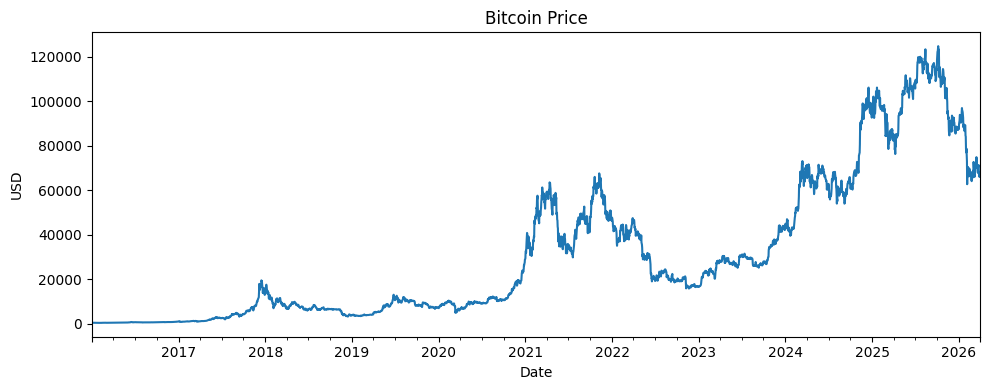

In [5]:
plt.figure(figsize=(10, 4))
df["price"].plot()
plt.title("Bitcoin Price")
plt.ylabel("USD")
plt.tight_layout()
plt.savefig("../output/figures/bitcoin_price.png", dpi=300)
plt.show()

#### b) Daily log returns

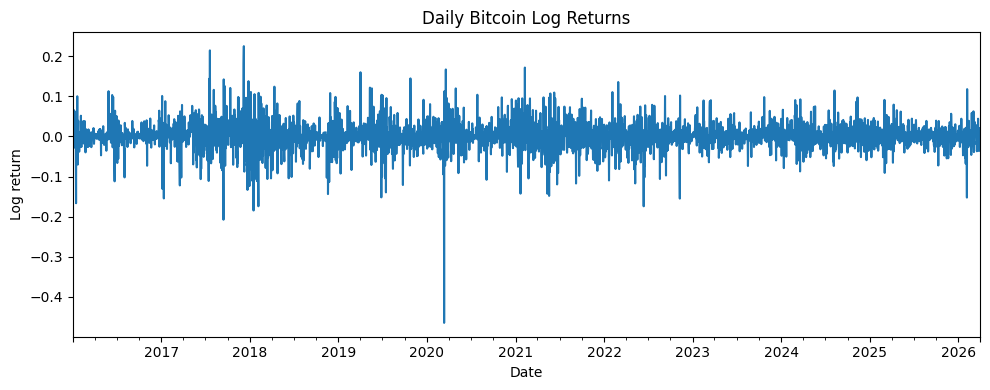

In [6]:
plt.figure(figsize=(10, 4))
df["log_return"].plot()
plt.title("Daily Bitcoin Log Returns")
plt.ylabel("Log return")
plt.tight_layout()
plt.savefig("../output/figures/bitcoin_log_returns.png", dpi=300)
plt.show()

#### c) Squared returns as a first view of volatility clustering

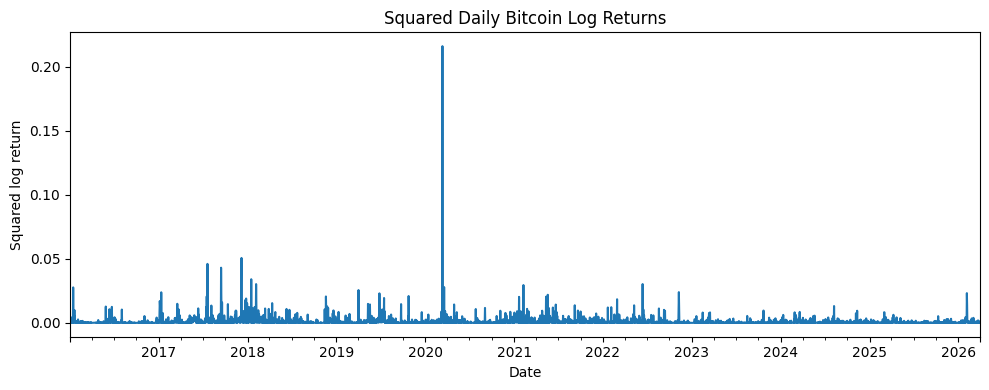

In [7]:
plt.figure(figsize=(10, 4))
(df["log_return"]**2).plot()
plt.title("Squared Daily Bitcoin Log Returns")
plt.ylabel("Squared log return")
plt.tight_layout()
plt.savefig("../output/figures/bitcoin_squared_returns.png", dpi=300)
plt.show()

### Descriptive statistics

In [8]:
desc = df["log_return"].describe()
skew = df["log_return"].skew()
kurt = df["log_return"].kurt()

print(desc)
print(f"Skewness: {skew:.4f}")
print(f"Kurtosis: {kurt:.4f}")

count    3742.000000
mean        0.001351
std         0.035250
min        -0.464730
25%        -0.012682
50%         0.001144
75%         0.015763
max         0.225119
Name: log_return, dtype: float64
Skewness: -0.6628
Kurtosis: 12.1836


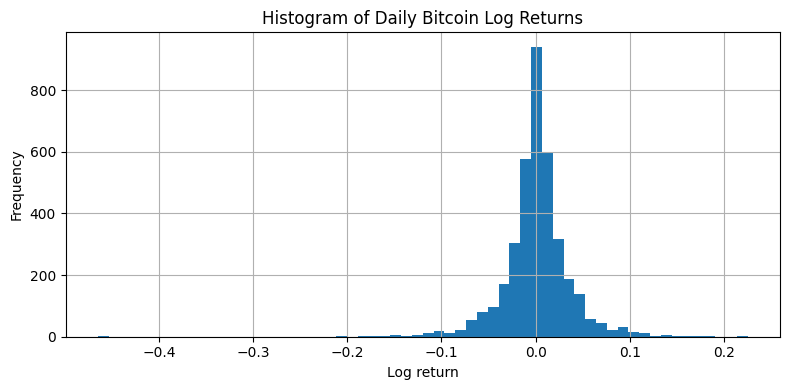

In [9]:
plt.figure(figsize=(8, 4))
df["log_return"].hist(bins=60)
plt.title("Histogram of Daily Bitcoin Log Returns")
plt.xlabel("Log return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../output/figures/bitcoin_return_histogram.png", dpi=300)
plt.show()